# Hahn-Echo-Train vs. CPMG — Einfluss reduzierter Refokussierungswinkel

Beide Sequenzen haben **dieselbe Anzahl von 120°-Refokussierungspulsen** und dasselbe TE.
Der einzige Unterschied ist die Phase des Refokussierungspulses:

| Variante | Phase φ | Fehler-Akkumulation |
|---|---|---|
| Hahn-Train | 0 (x-Achse) | Stimulierte Echos interferieren destruktiv → schneller Amplitudenabfall |
| CPMG | π/2 (y-Achse) | Alle Kohärenzpfade summieren konstruktiv → sauberer T₂-Zerfall |

**120°** ist ein klinisch typischer Flipwinkel in TSE/RARE-Sequenzen: reduzierter SAR (44% weniger als 180°)
bei gleichzeitig robuster T₂-Messung dank der Meiboom-Gill-Phasenbedingung.

In [41]:
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import pypulseq as pp
import matplotlib.pyplot as plt
import matplotlib as mpl

from bmc.simulate import simulate
from bmc.utils.seq.write import write_seq
from bmc.utils.results import save_simulation, load_simulation

## Einstellungen

In [42]:
# ── Pfade ──────────────────────────────────────────────────────────────────
wdir         = Path().resolve().parent
seq_dir      = wdir / 'seq_lib' / 'cpmg'
seq_dir.mkdir(parents=True, exist_ok=True)

series_label = datetime.now().strftime('%Y%m%d_%H%M%S')
config_file  = wdir / 'sim_lib' / 'config_t2fit_noex.yaml'

# ── Sequenz-Parameter ──────────────────────────────────────────────────────
sys = pp.Opts(
    max_grad=500, grad_unit='mT/m',
    max_slew=1e9, slew_unit='T/m/s',
    rf_ringdown_time=0, rf_dead_time=0,
    rf_raster_time=1e-6, gamma=42576400, grad_raster_time=1e-6,
)

B0             = 17
t_pulse        = 2e-3      # [s]  Pulsdauer
TE             = 30e-3     # [s]  Echo-Abstand
N_echoes       = 8         # Anzahl Refokussierungspulse (gleich für beide)
FA_refocus_deg = 120       # [°]  reduzierter Flipwinkel (klinisch typisch für SAR-Reduktion)
adc_time       = 30e-3     # [s]  Aufzeichnung nach letztem Delay

GAMMA_HZ = sys.gamma * 1e-6
freq_hz  = B0 * GAMMA_HZ

# ── Isochromaten ───────────────────────────────────────────────────────────
low, high, n_iso = -1e-3, 1e-3, 10000
z_pos = torch.sort(torch.cat((
    torch.tensor(np.linspace(low, high, n_iso)),
    torch.tensor([0.0])
))).values

# ── Analytische Echo-Zeiten (rekursiv, center-to-center) ───────────────────
# center_180_k = (k+0.5)*t_pulse + (k-0.5)*TE
# t_echo_k     = 2*center_180_k - t_echo_{k-1}
t_echo_s = [0.5 * t_pulse]
for k in range(1, N_echoes + 1):
    c_k = (k + 0.5) * t_pulse + (k - 0.5) * TE
    t_echo_s.append(2 * c_k - t_echo_s[k - 1])
t_echo_ms = np.array(t_echo_s[1:]) * 1e3   # [ms], nur als Suchfenster-Zentren

# ── Pools ──────────────────────────────────────────────────────────────────
n_total_pools = 2
mz_loc        = 4

print(f"TE          = {TE*1e3:.0f} ms  |  N_echoes = {N_echoes}  |  FA = {FA_refocus_deg}°")
print(f"Analytische Echo-Zeiten = {np.round(t_echo_ms, 1)} ms")

TE          = 30 ms  |  N_echoes = 8  |  FA = 120°
Analytische Echo-Zeiten = [ 35.  65.  99. 129. 163. 193. 227. 257.] ms


## Sequenzen erstellen

Schema: `90°_x → TE/2 → [170°_{x|y} → TE/2 → TE/2] × (N-1) → 170°_{x|y} → TE/2 → ADC`

Beide Sequenzen haben **identische Struktur und identische Flipwinkel (170°)**.
Einziger Unterschied: Phase der Refokussierungspulse (0 vs. π/2).

In [43]:
rf90 = pp.make_gauss_pulse(
    flip_angle=np.pi / 2, system=sys, duration=t_pulse,
    center_pos=0.5, freq_offset=0.0, phase_offset=0.0, return_gz=False,
)
rf90.freq_offset = 0.0

seq_files = {}
for name, phase_refocus in [('Hahn-Train', 0.0), ('CPMG', np.pi / 2)]:
    slug = name.lower().replace('-', '')

    rf170 = pp.make_gauss_pulse(
        flip_angle=np.deg2rad(FA_refocus_deg), system=sys, duration=t_pulse,
        center_pos=0.5, freq_offset=0.0, phase_offset=phase_refocus, return_gz=False,
    )
    rf170.freq_offset = 0.0

    seq = pp.Sequence()
    seq.add_block(rf90)
    seq.add_block(pp.make_delay(TE / 2))

    for k in range(N_echoes):
        seq.add_block(rf170)
        seq.add_block(pp.make_delay(TE / 2))   # echo forms just past end of this delay
        if k < N_echoes - 1:
            seq.add_block(pp.make_delay(TE / 2))   # spacing before next pulse

    seq.add_block(pp.make_adc(num_samples=1, duration=1e-3))

    defs = {
        'TE': TE, 'b0': B0, 'm0_offset': 0, 'n_ETM': N_echoes,
        'seq_id_string': f'{slug}_n{N_echoes}_te{int(TE*1e3):03d}ms_fa{FA_refocus_deg}',
        'offsets_ppm': np.array([0]), 'num_meas': 1, 'freq': freq_hz,
    }

    sf = seq_dir / f"{slug}_n{N_echoes}_te{int(TE*1e3):03d}ms_fa{FA_refocus_deg}.seq"
    write_seq(seq=seq, seq_defs=defs, filename=sf,
              author='DANIEL MIKSCH', use_matlab_names=True)
    seq_files[name] = sf
    print(f"✓ {name:<12}  φ = {phase_refocus/np.pi:.0f}π  |  {N_echoes} × {FA_refocus_deg}°-Pulse  →  {sf.name}")

✓ Hahn-Train    φ = 0π  |  8 × 120°-Pulse  →  hahntrain_n8_te030ms_fa120.seq
✓ CPMG          φ = 0π  |  8 × 120°-Pulse  →  cpmg_n8_te030ms_fa120.seq


## Simulation

In [44]:
results_dir = wdir / 'results' / 'simulations' / f"cpmg_compare_{series_label}"
results_dir.mkdir(parents=True, exist_ok=True)

sim_results = {}
for name, sf in seq_files.items():
    print(f"Simuliere: {name} ...")
    sim = simulate(
        config_file=config_file,
        seq_file=sf,
        z_positions=z_pos,
        adc_time=adc_time,
        iso_select=None,
        return_zmag=False,
        show_plot=False,
        webhook=False,
        plt_range=[0, 4],
        n_backlog='ALL',
    )
    slug = name.lower().replace('-', '')
    out = save_simulation(sim, label=slug, results_root=results_dir)
    sim_results[name] = out
    print(f"   → {out.name}")

print("\n✓ Simulation abgeschlossen")

Simuliere: Hahn-Train ...


BMCTool simulation: 100%|██████████| 26/26 [05:20<00:00, 12.33s/it]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/cpmg_compare_20260518_230941/hahntrain_20260518_231503
   → hahntrain_20260518_231503
Simuliere: CPMG ...


BMCTool simulation: 100%|██████████| 26/26 [06:01<00:00, 13.92s/it]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/cpmg_compare_20260518_230941/cpmg_20260518_232110
   → cpmg_20260518_232110

✓ Simulation abgeschlossen


## Vergleichsplot

**Oben:** Voller Zeitverlauf |M_xy| — alle 8 Echos beider Sequenzen.  
**Unten:** Echo-Amplituden vs. Echo-Nummer — CPMG folgt dem T₂-Zerfall, Hahn-Train weicht ab.

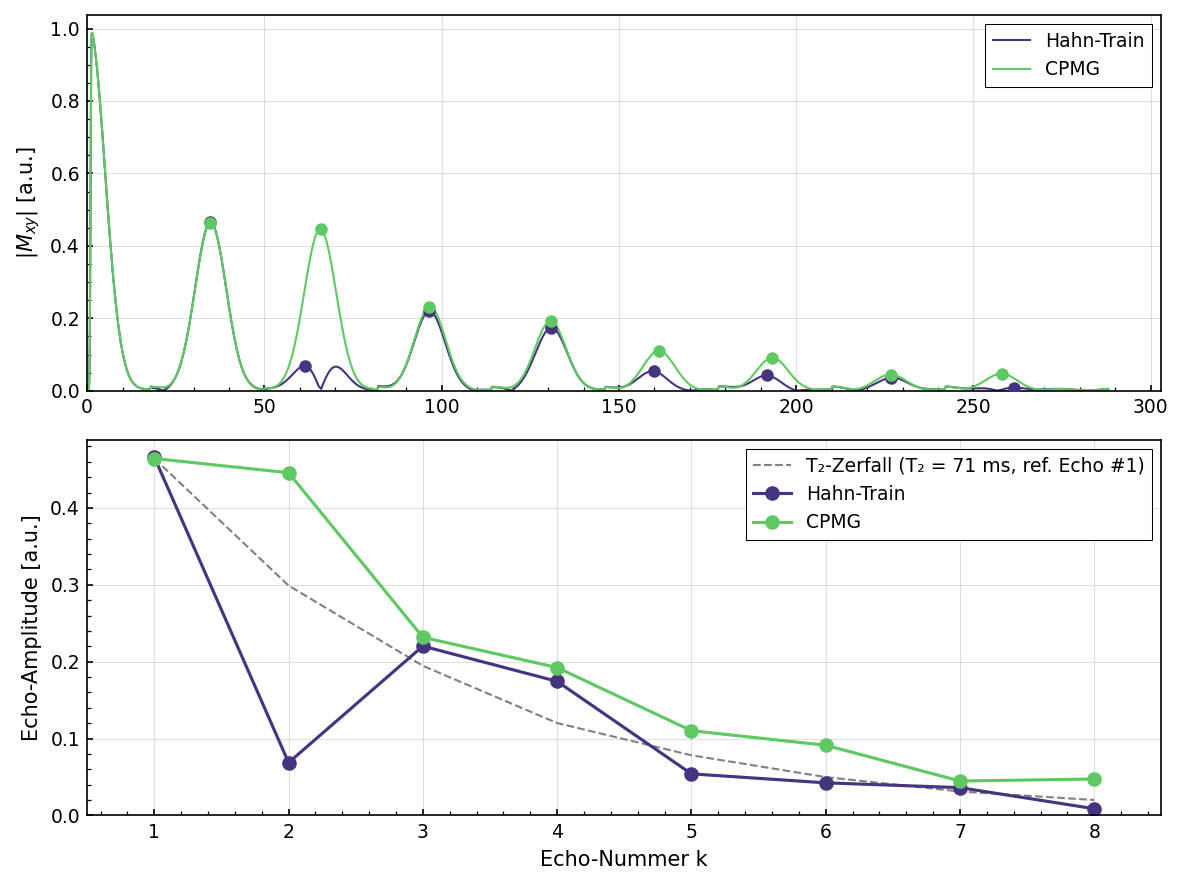


Echo      t_peak_CPMG       t_pred     Hahn-Train         CPMG       T₂-Ref
----------------------------------------------------------------------
  #1           34.8         35.0         0.4660       0.4642       0.4642
  #2           66.0         65.0         0.0686       0.4457       0.2989
  #3           96.5         99.0         0.2202       0.2317       0.1945
  #4          130.8        129.0         0.1743       0.1923       0.1201
  #5          161.3        163.0         0.0540       0.1101       0.0782
  #6          193.3        193.0         0.0423       0.0912       0.0498
  #7          226.8        227.0         0.0361       0.0447       0.0311
  #8          258.0        257.0         0.0086       0.0473       0.0200


In [45]:
cmap = plt.get_cmap('viridis')

mpl.rcParams.update({
    'font.family':          'sans-serif',
    'font.size':            10,
    'axes.labelsize':       10,
    'legend.fontsize':      9,
    'xtick.labelsize':      9,
    'ytick.labelsize':      9,
    'axes.linewidth':       0.8,
    'lines.linewidth':      1.5,
    'xtick.direction':      'in',
    'ytick.direction':      'in',
    'xtick.major.size':     3,
    'ytick.major.size':     3,
    'xtick.minor.visible':  True,
    'ytick.minor.visible':  True,
    'figure.dpi':           150,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
})

COLORS = {
    'Hahn-Train': cmap(0.15),
    'CPMG':       cmap(0.75),
}

# ── Daten laden & Echo-Amplituden extrahieren ───────────────────────────────
# Marker werden an der tatsächlichen Peak-Position gesetzt, nicht an der
# analytischen Echo-Zeit — wichtig wenn die Simulation leicht abweicht.
timecourse  = {}
echo_amps   = {}
echo_ts_act = {}   # tatsächliche Peak-Zeiten aus der Simulation

SEARCH_WIN_MS = 8.0   # [ms] Suchfenster um analytische Echo-Zeit

for name, out_dir in sim_results.items():
    loaded       = load_simulation(out_dir)
    m_out        = loaded['m_out']
    t            = loaded['t']
    n_iso_loaded = m_out.shape[0]

    m_x  = np.sum(m_out[:, 0,            :], axis=0) / n_iso_loaded
    m_y  = np.sum(m_out[:, n_total_pools, :], axis=0) / n_iso_loaded
    mxy  = np.abs(m_x + 1j * m_y)
    t_ms = t * 1e3
    timecourse[name] = (t_ms, mxy)

    amps, peak_ts = [], []
    for t_e in t_echo_ms:
        mask = np.abs(t_ms - t_e) < SEARCH_WIN_MS
        if mask.sum() > 0:
            idx_max = np.where(mask)[0][np.argmax(mxy[mask])]
        else:
            idx_max = int(np.argmin(np.abs(t_ms - t_e)))
        amps.append(float(mxy[idx_max]))
        peak_ts.append(float(t_ms[idx_max]))   # tatsächliche Zeit des Maximums
    echo_amps[name]   = np.array(amps)
    echo_ts_act[name] = np.array(peak_ts)

# ── Plot 1: Voller Zeitverlauf ──────────────────────────────────────────────
t_total_ms = (t_pulse + TE/2 + N_echoes*(t_pulse + TE) + adc_time) * 1e3

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

for name, (t_ms, mxy) in timecourse.items():
    color = COLORS[name]
    axes[0].plot(t_ms, mxy, '-', color=color, linewidth=1.0, label=name)
    axes[0].plot(echo_ts_act[name], echo_amps[name],
                 'o', color=color, markersize=5, zorder=5)

axes[0].set_xlim(0, t_total_ms)
axes[0].set_ylim(0, None)
axes[0].set_ylabel('$|M_{xy}|$ [a.u.]')
axes[0].grid(True, linewidth=0.4, color='gray', alpha=0.3)
leg0 = axes[0].legend(loc='upper right', frameon=True, fancybox=False,
                      framealpha=1.0, edgecolor='black')
leg0.get_frame().set_linewidth(0.5)

# ── Plot 2: Echo-Amplituden vs. Echo-Nummer ─────────────────────────────────
echo_nums = np.arange(1, N_echoes + 1)
T2_ms     = 71.0
amp0_cpmg = echo_amps['CPMG'][0]
ref_curve  = amp0_cpmg * np.exp(-(echo_ts_act['CPMG'] - echo_ts_act['CPMG'][0]) / T2_ms)

axes[1].plot(echo_nums, ref_curve, '--', color='gray', linewidth=1.0,
             label=f'T₂-Zerfall (T₂ = {T2_ms:.0f} ms, ref. Echo #1)')
for name in ['Hahn-Train', 'CPMG']:
    color = COLORS[name]
    axes[1].plot(echo_nums, echo_amps[name], 'o-', color=color,
                 markersize=6, linewidth=1.5, label=name)

axes[1].set_xlabel('Echo-Nummer k')
axes[1].set_ylabel('Echo-Amplitude [a.u.]')
axes[1].set_xlim(0.5, N_echoes + 0.5)
axes[1].set_ylim(0, None)
axes[1].set_xticks(echo_nums)
axes[1].grid(True, linewidth=0.4, color='gray', alpha=0.3)
leg1 = axes[1].legend(loc='upper right', frameon=True, fancybox=False,
                      framealpha=1.0, edgecolor='black')
leg1.get_frame().set_linewidth(0.5)

fig.tight_layout()
fig.savefig(results_dir / f'hahn_vs_cpmg_{series_label}.pdf')
fig.savefig(results_dir / f'hahn_vs_cpmg_{series_label}.png')
plt.show()

print(f"\n{'Echo':<6} {'t_peak_CPMG':>14} {'t_pred':>12} {'Hahn-Train':>14} {'CPMG':>12} {'T₂-Ref':>12}")
print('-' * 70)
for k in range(N_echoes):
    ref = amp0_cpmg * np.exp(-(echo_ts_act['CPMG'][k] - echo_ts_act['CPMG'][0]) / T2_ms)
    print(f"  #{k+1}   {echo_ts_act['CPMG'][k]:>12.1f}   {t_echo_ms[k]:>10.1f}"
          f"   {echo_amps['Hahn-Train'][k]:>12.4f}   {echo_amps['CPMG'][k]:>10.4f}   {ref:>10.4f}")

## Parameter

| Parameter | Wert |
|---|---|
| Anzahl Refokussierungspulse | **8** (gleich für beide Sequenzen) |
| TE | 30 ms |
| Flipwinkel | **120°** (klinisch typisch; SAR ∝ FA² → nur 44% des 180°-SAR) |
| Hahn-Train Phase | 0 (x-Achse, kein Phasenwechsel) |
| CPMG Phase | π/2 (y-Achse, Meiboom-Gill-Bedingung) |
| T₁ / T₂ (Wasser) | 2.5 s / 71 ms |
| b0_inhom | 3×10⁻⁸ → T₂* ≈ 10 ms |
| Isochromaten | 101 |

**Erwartetes Verhalten mit 120°:**
- **CPMG (120°):** Echo-Amplituden folgen dem T₂-Zerfall — alle Kohärenzpfade (primär + stimuliert) summieren konstruktiv. Amplitude etwas geringer als bei 180° (Faktor ≈ sin²(60°) = 0.75).
- **Hahn-Train (120°):** Deutlich stärkere Abweichung als bei 170°, da der 60°-Fehler (statt 10°) mehr Magnetisierung nach Z transferiert → stärkere Stimulierte-Echo-Interferenz.